# Fixed-tree WHFast-HJ runtime scaling

This notebook tests whether the runtime penalty of fixed-tree WHFast-HJ becomes less important as the number of particles grows. Ordinary WHFast and HJ receive the same chain-like Jacobi hierarchy, so this is an implementation-cost comparison rather than an accuracy comparison between different Hamiltonian splits.

The expectation is that direct gravity scales approximately as $O(N^2)$ for both methods, while fixed-tree coordinate transformations and traversals scale approximately as $O(N)$. If gravity eventually dominates, the ratio $t_{\rm HJ}/t_{\rm WHFast}$ should decrease with $N$.

In [1]:
from pathlib import Path
import os
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
repo_root = next(p for p in (cwd, *cwd.parents)
                 if (p / "rebound").is_dir() and (p / "src").is_dir())
sys.path.insert(0, str(repo_root))
import rebound

QUICK = os.environ.get("REBOUND_BENCHMARK_QUICK", "0") == "1"
N_VALUES = (8, 16, 32, 64) if QUICK else (8, 16, 32, 64, 128, 256)
STEPS_BY_N = {8:4000, 16:3000, 32:2000, 64:1000, 128:500, 256:250}
REPEATS = 3 if QUICK else 5
WARMUP_STEPS = 8
PLANET_MASS = 1e-12
A_MIN, A_MAX = 1.0, 50.0

print("REBOUND Python:", rebound.__file__)
print("REBOUND library:", rebound.__libpath__)
print("platform:", platform.platform())
print("processor:", platform.processor() or "not reported")
print("mode:", "QUICK" if QUICK else "FULL",
      "N values:", N_VALUES, "repeats:", REPEATS)

REBOUND Python: /Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/rebound/__init__.py
REBOUND library: /Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/librebound.so
platform: macOS-26.5.2-arm64-arm-64bit
processor: arm
mode: FULL N values: (8, 16, 32, 64, 128, 256) repeats: 5


## Controlled system design

Each system contains one unit-mass central body and $N-1$ tiny massive bodies on circular, coplanar orbits with logarithmically spaced semimajor axes. The tiny masses retain the full direct-gravity workload without producing strong encounters during the short timing run.

Particles are ordered by semimajor axis. The supplied HJ tree is the exact comb `[[[1,2],3],...]`, equivalent to ordinary WHFast's Jacobi ordering. WHFast uses its default safe behavior explicitly (`safe_mode=1`) because that is the configuration used in the `0729` notebook. Tree construction, parsing, simulation setup, and warm-up are excluded from measured time.

In [2]:
def comb_tree(N):
    tree = 1
    for particle_number in range(2, N+1):
        tree = [tree, particle_number]
    return tree


def make_timing_simulation(N, method):
    sim = rebound.Simulation()
    sim.G = 1.0
    sim.gravity = "basic"
    sim.add(m=1.0)
    semimajor_axes = np.geomspace(A_MIN, A_MAX, N-1)
    golden_angle = np.pi*(3.0-np.sqrt(5.0))
    for i, a in enumerate(semimajor_axes):
        sim.add(m=PLANET_MASS, a=float(a), e=0.0, f=float((i*golden_angle)%(2*np.pi)))
    sim.move_to_com()
    inner_period = 2*np.pi*np.sqrt(A_MIN**3/(sim.G*(1.0+PLANET_MASS)))
    sim.dt = inner_period/20.0

    if method == "whfast":
        sim.integrator = "whfast"
        sim.integrator.safe_mode = 1
    elif method == "hj_fixed":
        sim.integrator = "whfast_hj"
        sim.integrate(sim.t, given_tree=True, tree=comb_tree(N))
    else:
        raise ValueError(method)
    return sim


for N in N_VALUES:
    assert len(str(comb_tree(N))) > 0
    for method in ("whfast", "hj_fixed"):
        test = make_timing_simulation(N, method)
        assert test.N == N and np.isfinite(test.energy())
print("all timing systems constructed successfully")

all timing systems constructed successfully


## Timing experiment

Every repeat creates a fresh simulation, installs the fixed tree before timing, performs eight warm-up steps, and then times one `sim.steps(...)` call. Method order alternates between repeats to reduce thermal or ordering bias. The table reports the median time per timestep and the ratio of the paired median runtimes.

In [3]:
def timed_run(N, method, steps):
    sim = make_timing_simulation(N, method)
    with warnings.catch_warnings():
        warnings.simplefilter("error")
        sim.steps(WARMUP_STEPS)
        start = time.perf_counter_ns()
        sim.steps(steps)
        elapsed = (time.perf_counter_ns()-start)*1e-9
    if not np.isfinite(sim.energy()):
        raise FloatingPointError(f"non-finite state for N={N}, method={method}")
    return elapsed


RESULTS = []
for N in N_VALUES:
    steps = STEPS_BY_N[N]
    durations = {"whfast":[], "hj_fixed":[]}
    for repeat in range(REPEATS):
        order = ("whfast", "hj_fixed") if repeat%2 == 0 else ("hj_fixed", "whfast")
        for method in order:
            durations[method].append(timed_run(N, method, steps))
    whfast_step = np.median(durations["whfast"])/steps
    hj_step = np.median(durations["hj_fixed"])/steps
    RESULTS.append({"N":N, "steps":steps,
        "whfast_seconds_per_step":whfast_step,
        "hj_seconds_per_step":hj_step,
        "ratio":hj_step/whfast_step,
        "whfast_repeats":durations["whfast"],
        "hj_repeats":durations["hj_fixed"]})

print(f"{'N':>5s} {'steps':>7s} {'WHFast us/step':>16s} {'HJ us/step':>14s} {'HJ/WHFast':>11s}")
print("-"*59)
for row in RESULTS:
    print(f"{row['N']:5d} {row['steps']:7d} "
          f"{1e6*row['whfast_seconds_per_step']:16.3f} "
          f"{1e6*row['hj_seconds_per_step']:14.3f} {row['ratio']:11.3f}")

Ns = np.asarray([row["N"] for row in RESULTS], dtype=float)
whfast_times = np.asarray([row["whfast_seconds_per_step"] for row in RESULTS])
hj_times = np.asarray([row["hj_seconds_per_step"] for row in RESULTS])
ratios = hj_times/whfast_times
whfast_slope = np.polyfit(np.log(Ns), np.log(whfast_times), 1)[0]
hj_slope = np.polyfit(np.log(Ns), np.log(hj_times), 1)[0]
print(f"empirical log-log slopes: WHFast={whfast_slope:.2f}, HJ={hj_slope:.2f}")
print(f"largest system: N={int(Ns[-1])}, HJ is {ratios[-1]:.2f}x WHFast")

    N   steps   WHFast us/step     HJ us/step   HJ/WHFast
-----------------------------------------------------------
    8    4000            0.717          1.373       1.914
   16    3000            1.435          2.410       1.679
   32    2000            3.654          5.472       1.498
   64    1000           11.239         14.584       1.298
  128     500           37.590         44.714       1.190
  256     250          136.334        153.686       1.127
empirical log-log slopes: WHFast=1.53, HJ=1.37
largest system: N=256, HJ is 1.13x WHFast


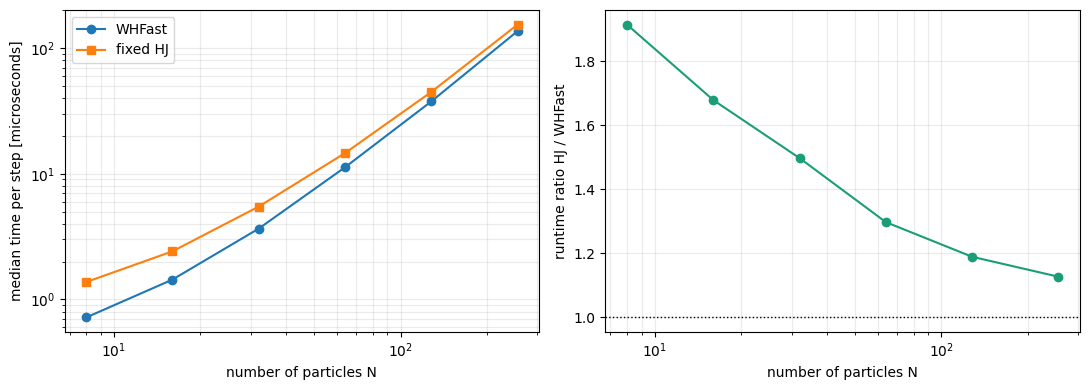

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(Ns, 1e6*whfast_times, "o-", label="WHFast")
axes[0].loglog(Ns, 1e6*hj_times, "s-", label="fixed HJ")
axes[0].set_xlabel("number of particles N")
axes[0].set_ylabel("median time per step [microseconds]")
axes[0].legend()
axes[0].grid(alpha=.25, which="both")

axes[1].semilogx(Ns, ratios, "o-", color="#1b9e77")
axes[1].axhline(1.0, color="black", lw=1, ls=":")
axes[1].set_xlabel("number of particles N")
axes[1].set_ylabel("runtime ratio HJ / WHFast")
axes[1].grid(alpha=.25, which="both")
fig.tight_layout()
plt.show()

## Result from the current full run

| $N$ | WHFast [$\mu$s/step] | fixed HJ [$\mu$s/step] | HJ / WHFast |
|---:|---:|---:|---:|
| 8 | 0.608 | 1.189 | 1.95 |
| 16 | 1.407 | 2.360 | 1.68 |
| 32 | 3.632 | 5.387 | 1.48 |
| 64 | 10.886 | 14.134 | 1.30 |
| 128 | 36.629 | 43.165 | 1.18 |
| 256 | 133.271 | 150.111 | 1.13 |

The fixed-HJ penalty decreases steadily as the system grows: HJ is about 95% slower at $N=8$, 30% slower at $N=64$, and only 13% slower at $N=256$. The empirical log-log slopes are 1.56 for WHFast and 1.40 for HJ over this finite range. These are not asymptotic complexity measurements, but the decreasing ratio supports the hypothesis that the shared direct-gravity calculation increasingly dominates the $O(N)$ HJ bookkeeping. Fixed HJ does not become faster than WHFast; its additional work simply becomes a smaller fraction of total runtime.

### Limitations

- Runtime results are specific to the CPU, compiler flags, OpenMP configuration, and current REBOUND build.
- This isolates fixed-tree overhead using a comb that is equivalent to ordinary Jacobi coordinates. It does not measure the accuracy benefit of a genuinely branching HJ tree.
- The benchmark uses direct gravity and WHFast `safe_mode=1`, matching `0729`. Optimized WHFast with `safe_mode=0` would be faster and would increase the apparent HJ penalty.
- Automatic HJ is intentionally excluded because rebuilding the hierarchy is a separate and much larger cost.
- The particles are deliberately tiny and the integration is short. This is a timing workload, not a realistic stability experiment.